In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
exports = pd.read_excel("data/India Export Data.xlsx")
imports = pd.read_excel("data/India Import Data.xlsx")


In [3]:
exports["Partner Name"] = exports["Partner Name"].str.strip()
imports["Partner Name"] = imports["Partner Name"].str.strip()

In [4]:

exports_world = exports[exports["Partner Name"].str.lower() == "world"]
imports_world = imports[imports["Partner Name"].str.lower() == "world"]

year_columns = exports.columns[5:]

In [5]:
exports_values = exports_world.iloc[0][year_columns].values
imports_values = imports_world.iloc[0][year_columns].values

trade_df = pd.DataFrame({
    "Year": year_columns,
    "Exports": exports_values,
    "Imports": imports_values
})


In [6]:
trade_df["Year"] = trade_df["Year"].astype(int)

# Convert to Billion USD
trade_df["Exports"] = trade_df["Exports"] / 1_000_000
trade_df["Imports"] = trade_df["Imports"] / 1_000_000
trade_df["Trade Balance"] = trade_df["Exports"] - trade_df["Imports"]

In [7]:
print(trade_df.head())

   Year    Exports    Imports Trade Balance
0  1988  13.872437  19.350897     -5.478459
1  1989  17.045032  21.718194     -4.673162
2  1990  17.940183  23.799151     -5.858968
3  1991  17.899887  19.509416     -1.609529
4  1992  20.711291  24.452408     -3.741117


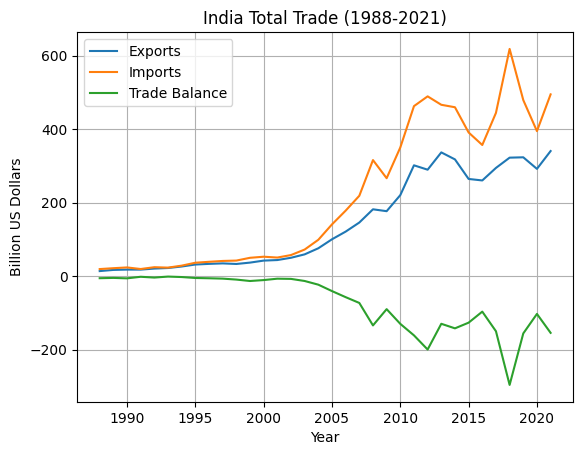

In [8]:
plt.figure()
plt.plot(trade_df["Year"], trade_df["Exports"], label="Exports")
plt.plot(trade_df["Year"], trade_df["Imports"], label="Imports")
plt.plot(trade_df["Year"], trade_df["Trade Balance"], label="Trade Balance")

plt.xlabel("Year")
plt.ylabel("Billion US Dollars")
plt.title("India Total Trade (1988-2021)")
plt.legend()
plt.grid()
plt.show()


In [9]:
print("\nHighest Export Year:")
print(trade_df.loc[trade_df["Exports"].idxmax()])

print("\nHighest Import Year:")
print(trade_df.loc[trade_df["Imports"].idxmax()])

print("\nWorst Trade Deficit Year:")
print(trade_df.loc[trade_df["Trade Balance"].idxmin()])


Highest Export Year:
Year                  2021
Exports           340.2728
Imports          494.34235
Trade Balance   -154.06955
Name: 33, dtype: object

Highest Import Year:
Year                   2018
Exports          322.291568
Imports          617.945603
Trade Balance   -295.654035
Name: 30, dtype: object

Worst Trade Deficit Year:
Year                   2018
Exports          322.291568
Imports          617.945603
Trade Balance   -295.654035
Name: 30, dtype: object


C:\Users\iamsu\AppData\Local\Temp\ipykernel_6848\290928581.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trade_df["Export Growth %"] = trade_df["Exports"].pct_change() * 100
C:\Users\iamsu\AppData\Local\Temp\ipykernel_6848\290928581.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trade_df["Import Growth %"] = trade_df["Imports"].pct_change() * 100


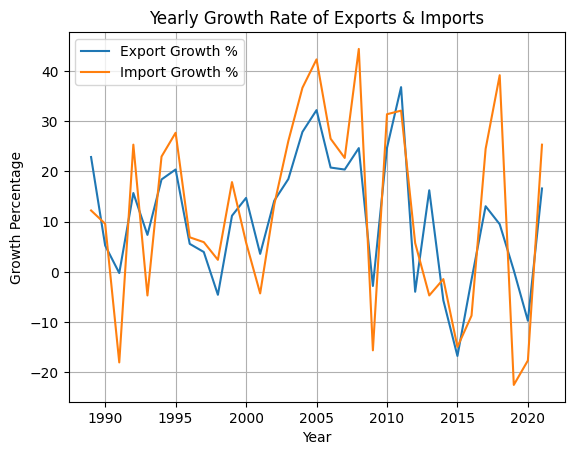

In [10]:
def country_trade(country_name):
    exp = exports[exports["Partner Name"].str.lower() == country_name.lower()]
    imp = imports[imports["Partner Name"].str.lower() == country_name.lower()]

    if len(exp) == 0 or len(imp) == 0:
        print(f"No data for {country_name}")
        return

    exp_values = exp.iloc[0][year_columns].values / 1_000_000
    imp_values = imp.iloc[0][year_columns].values / 1_000_000

    plt.figure()
    plt.plot(trade_df["Year"], exp_values, label=f"{country_name} Exports")
    plt.plot(trade_df["Year"], imp_values, label=f"{country_name} Imports")

    plt.xlabel("Year")
    plt.ylabel("Billion US Dollars")
    plt.title(f"India Trade with {country_name}")
    plt.legend()
    plt.grid()
    plt.show()
trade_df["Export Growth %"] = trade_df["Exports"].pct_change() * 100
trade_df["Import Growth %"] = trade_df["Imports"].pct_change() * 100

plt.figure()
plt.plot(trade_df["Year"], trade_df["Export Growth %"], label="Export Growth %")
plt.plot(trade_df["Year"], trade_df["Import Growth %"], label="Import Growth %")
plt.xlabel("Year")
plt.ylabel("Growth Percentage")
plt.title("Yearly Growth Rate of Exports & Imports")
plt.legend()
plt.grid()
plt.show()

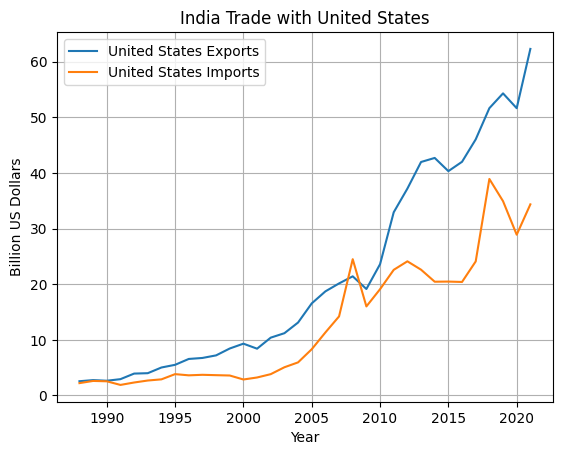

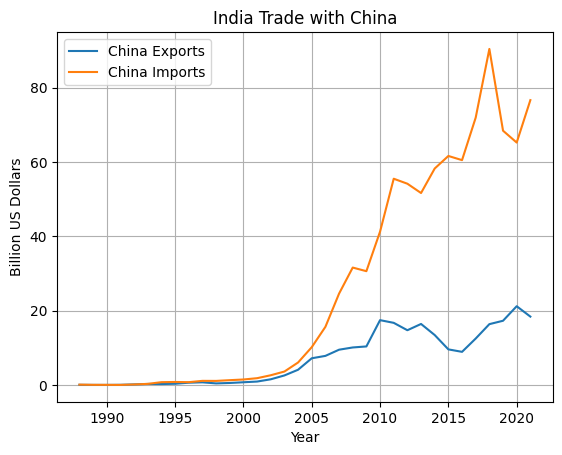


Top 10 Export Partners (2021):
             Partner Name         2021
0                   World  340272800.0
237         United States   62276690.0
235  United Arab Emirates   22359440.0
44                  China   18396780.0
18             Bangladesh   12960400.0
157           Netherlands    9273500.0
105      Hong Kong, China    9210120.0
201             Singapore    9057570.0
236        United Kingdom    8531300.0
89                Germany    7917530.0

Excel file created: India_Trade_Analysis_Output.xlsx


In [11]:
country_trade("United States")
country_trade("China")


latest_year = 2021
top_exports = exports[["Partner Name", latest_year]].sort_values(
    by=latest_year, ascending=False
).head(10)

print("\nTop 10 Export Partners (2021):")
print(top_exports)



trade_df.to_excel("India_Trade_Analysis_Output.xlsx", index=False)
print("\nExcel file created: India_Trade_Analysis_Output.xlsx")

2026-04-15 12:14:56.573 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 12:14:56.963 
  command:

    streamlit run C:\Users\iamsu\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-15 12:14:56.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 12:14:56.966 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 12:14:56.968 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 12:14:56.969 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 12:14:56.969 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 12:14:56.971 Thre

DeltaGenerator()

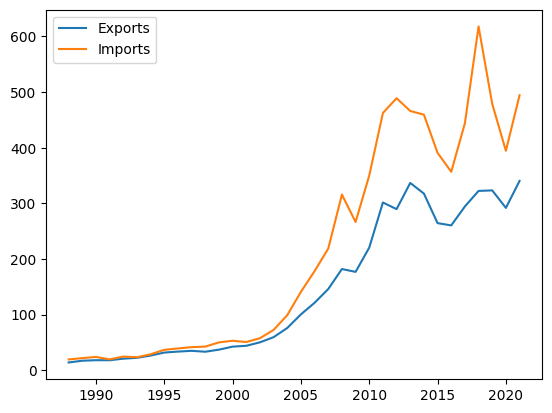

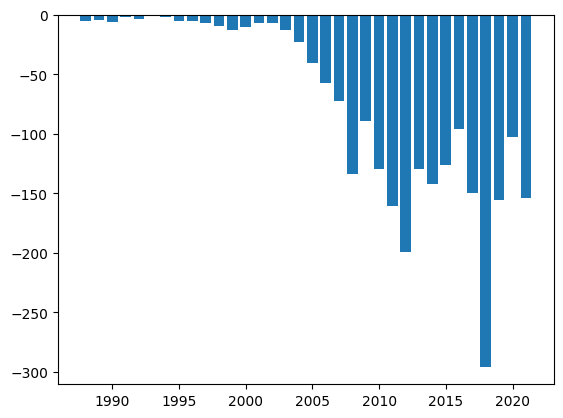

In [12]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("India_Trade_Analysis_Output.xlsx")

st.title("India Trade Analysis Dashboard")

# KPIs
st.subheader("Key Metrics")
col1, col2, col3 = st.columns(3)

col1.metric("Total Exports", f"{df['Exports'].sum():,.2f}")
col2.metric("Total Imports", f"{df['Imports'].sum():,.2f}")
col3.metric("Trade Balance", f"{df['Trade Balance'].sum():,.2f}")

# Line Chart
st.subheader("Trade Trend")

plt.figure()
plt.plot(df["Year"], df["Exports"], label="Exports")
plt.plot(df["Year"], df["Imports"], label="Imports")
plt.legend()
st.pyplot(plt)

# Trade Balance
st.subheader("Trade Balance")

plt.figure()
plt.bar(df["Year"], df["Trade Balance"])
st.pyplot(plt)